<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [82]:
# loading the data: Wholesale customers data
data = pd.read_csv(r"C:\Users\nahia\OneDrive\Escritorio\Ironhack_Bootcamp\Woche_Fünf\lab-unsupervised-learning-en_a\data\Wholesale customers data.csv")

In [83]:
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
unique_region_values = data["Region"].unique()
print(unique_region_values)

[3 1 2]


### Question 1
What does each column mean?
Answer: a category of products that are sell in a grocery store.

### Question 2 
Any categorical data to convert?
All the values are numerical continuos, so the answer is no.

### Question 3
Any missing data to remove?

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


###  Answer
There is not data missing or needed to be remove

Column Channel and Region

In [32]:
data = data.drop(['Channel', 'Region'], axis=1)

In [84]:
data.head

<bound method NDFrame.head of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4  

#### Question 4
Column collinearity - any high correlations?

In [34]:
corr = data.corr(numeric_only=True)
print(corr)

                     Fresh      Milk   Grocery    Frozen  Detergents_Paper  \
Fresh             1.000000 -0.110624 -0.172917  0.285739         -0.255098   
Milk             -0.110624  1.000000  0.737114 -0.054464          0.664013   
Grocery          -0.172917  0.737114  1.000000 -0.165770          0.868698   
Frozen            0.285739 -0.054464 -0.165770  1.000000         -0.217035   
Detergents_Paper -0.255098  0.664013  0.868698 -0.217035          1.000000   
Delicassen        0.171666  0.309870  0.250265  0.140354          0.125066   

                  Delicassen  
Fresh               0.171666  
Milk                0.309870  
Grocery             0.250265  
Frozen              0.140354  
Detergents_Paper    0.125066  
Delicassen          1.000000  


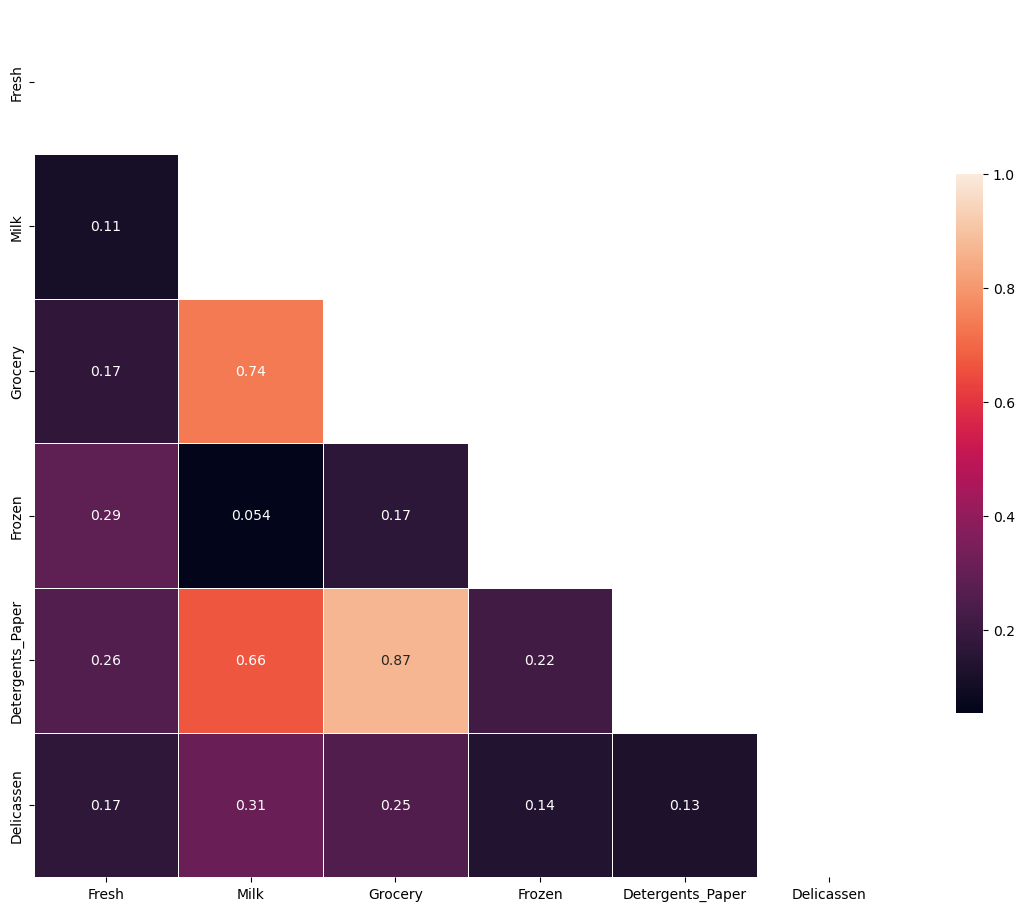

In [35]:
import matplotlib.pyplot as plt
import seaborn as sn

corr=np.abs(data.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(14, 14))
# Generate a custom diverging colormap
cmap = sn.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sn.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

Grocery and Detergents_Paper show a siginificant collinearity, grocery and milk show a moderate collinearity

### Descriptive statistics - any outliers to remove?

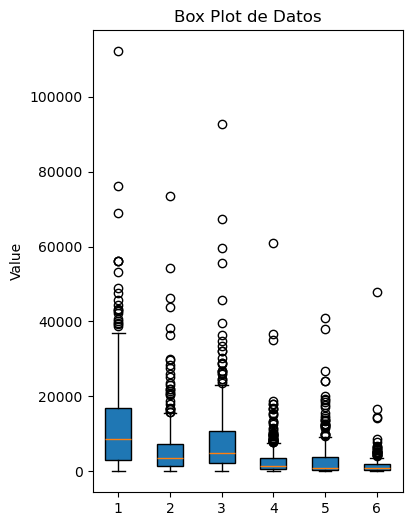

In [85]:
plt.figure(figsize=(4,6))
plt.boxplot(data[customer_preferences], vert=True, patch_artist=True)
plt.title('Box Plot de Datos')
plt.ylabel('Value')
plt.show()

In [25]:
limite = 33000

data = data[(data.select_dtypes(include='number') <= limite).all(axis=1)]

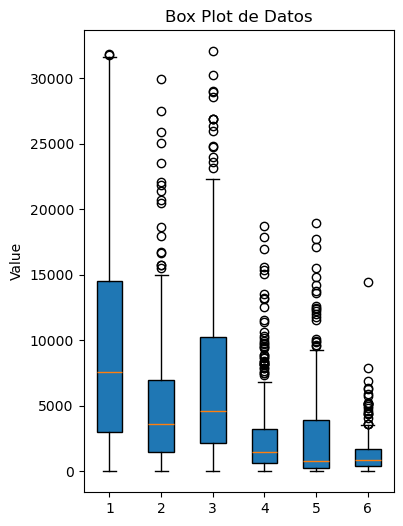

In [26]:
plt.figure(figsize=(4,6))
plt.boxplot(data[customer_preferences], vert=True, patch_artist=True)
plt.title('Box Plot de Datos')
plt.ylabel('Value')
plt.show()

## The range between categories is significantly different

### Column-wise data distribution - is the distribution skewed?

In [55]:
skewness = data.skew()
print(skewness)

Fresh               0.901265
Milk                1.929163
Grocery             1.465412
Frozen              2.329752
Detergents_Paper    1.998836
Delicassen          3.473883
Total               0.963537
dtype: float64


Fresh  → right-skewed
Milk → right-skewed
Grocery→ right-skewed
Frozen → right-skewed
Detergents_Paper → right-skewed
Delicassen → right-skewed


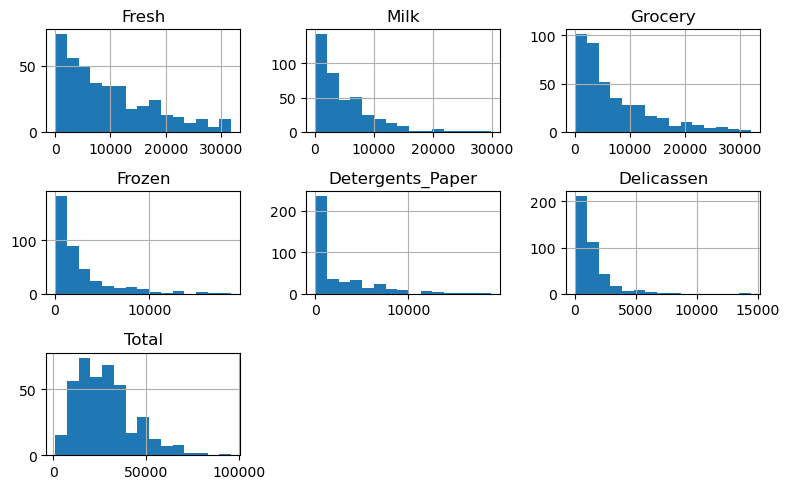

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
data.hist(bins=15, figsize=(8,5))
plt.tight_layout()
plt.show()






Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [90]:
data['Total'] = data.sum(axis=1)

In [91]:
data.head

<bound method NDFrame.head of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  Total  
0          1338  34117  
1          1776  33271  
2          7844  3

In [86]:
data = data.reset_index(drop=True)

In [87]:
data.head

<bound method NDFrame.head of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4  

In [92]:
440*.20


88.0

In [93]:
data = data.sort_values(by='Total', ascending=False)

In [94]:
total_sum = data['Total'].sum()
print("total sum:", total_sum)

total sum: 14621201


In [98]:
partial_sum = data['Total'].iloc[:88].sum()
print(f"Sum up to reach 20% of the customers {88}:", partial_sum)

Sum up to reach 20% of the customers 88: 6272835


In [97]:
a = partial_sum / total_sum 
print(a)

0.42902323824150973


in this particular case , the Pareto rule is not met.

**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [ ]:
# Your code here


**Your comment here**

-  ...
-  ...

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

tengo que importar la version final

In [46]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)
from sklearn.preprocessing import StandardScaler

In [47]:
# Your import here:

data1 = pd.read_csv(r"C:\Users\nahia\OneDrive\Escritorio\Ironhack_Bootcamp\Woche_Fünf\lab-unsupervised-learning-en_a\data\Wholesale customers data.csv")




In [48]:
data1.head

<bound method NDFrame.head of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4  

In [49]:
data1 = data1.reset_index(drop=True)

In [50]:
data1.head

<bound method NDFrame.head of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4  

In [53]:
data1 = data1.drop(['Channel', 'Region'], axis=1)

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data1_scaled = scaler.fit_transform(data1) 

In [63]:
from sklearn.cluster import KMeans

In [64]:
inertia = []
K = range(1, 10)  

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data1)
    inertia.append(kmeans.inertia_)

c:\Users\nahia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\nahia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\nahia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\nahia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

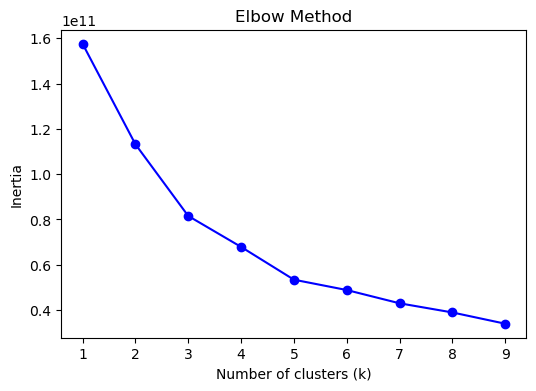

In [65]:
plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [66]:
from sklearn.cluster import KMeans

# Your code here:
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model
kmeans.fit(data1_scaled)

# Get cluster labels
labels = kmeans.labels_




print(labels)


[3 0 0 3 3 3 3 3 3 0 0 3 0 0 0 3 0 3 3 3 3 3 3 1 0 3 3 3 0 3 3 3 3 3 3 0 3
 0 0 3 3 3 0 0 0 0 0 2 0 0 3 3 3 0 3 3 2 0 3 3 3 2 3 0 3 2 3 0 3 3 3 1 3 3
 3 3 3 0 3 3 3 0 0 3 3 2 2 1 3 3 3 3 2 1 0 3 3 3 3 3 0 0 0 3 3 3 0 0 0 0 3
 0 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 0 3 3
 3 3 3 3 3 3 3 0 0 3 0 0 0 3 3 0 0 0 0 3 3 3 0 0 3 0 3 0 3 3 3 3 3 1 0 1 3
 3 3 0 0 0 3 3 3 0 3 3 3 0 3 3 0 0 3 3 3 0 3 3 3 0 3 2 3 0 0 0 0 3 0 3 3 0
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 0 0 3 3 3 3 3 2 3 3 0 3 3 3 3
 3 3 3 3 3 0 0 0 3 0 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 0 3 3
 3 3 0 3 3 0 0 0 0 0 0 3 3 0 3 3 0 3 3 0 3 3 3 0 3 3 3 3 3 1 3 3 3 3 3 0 3
 2 3 3 3 3 3 3 0 0 0 0 3 3 0 3 3 0 3 0 3 0 3 3 3 0 0 3 3 3 3 3 3 0 3 3 3 3
 3 3 3 3 3 3 0 3 3 3 3 3 3 3 0 3 3 3 3 3 3 3 3 3 3 3 0 3 3 3 3 3 3 3 3 3 3
 0 3 3 3 3 0 3 3 3 0 0 0 3 0 3 3 3 3 3 0 3 3 3 0 3 3 3 3 3 3 0 3 3]


c:\Users\nahia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


### Looking to the elbow we can choose 2 like the correct number of clusters

In [67]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=2, random_state=42)

# Fit the model
kmeans.fit(data1_scaled)

# Get cluster labels
labels = kmeans.labels_


data1['labels'] = labels

print(labels)

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1
 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0]


c:\Users\nahia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Count the values in `labels`.

In [68]:
# Your code here:
len(labels)

440

In [85]:
data1['labels'] = labels

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [86]:


# Your code here
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

Count the values in `labels_DBSCAN`.

In [87]:
# Your code here

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data1) 

In [88]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(data_scaled)

DBSCAN()

In [89]:
labels = dbscan.labels_
print(labels)

[ 0  0 -1  0 -1  0  0  0  0 -1 -1  0 -1 -1 -1  0  0 -1  0  0  0  0 -1 -1
 -1  0  0  0 -1  1 -1  0  0 -1  0  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  0 -1  0  0 -1  0 -1  0 -1 -1  0  0  0 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1
 -1 -1  0  0 -1 -1  0  0  0  0  0  0  0 -1 -1 -1  0 -1  0  0 -1 -1  0  0
 -1  0  0  0 -1 -1  0 -1  0  0  0 -1  0 -1  0 -1 -1  0  0  0  0  0  0  0
  0  0  0 -1 -1 -1 -1 -1  0  1  0  0  0  0  0  0 -1 -1 -1  0  0 -1 -1  0
  0 -1  0  0  0 -1  0  0  0 -1  0 -1 -1  0  0  0  0  0  0 -1 -1 -1 -1  0
  0  0  0 -1  0 -1  0  0 -1 -1  0 -1  0 -1  0 -1  0  0  0 -1 -1  0 -1  0
  0 -1  0 -1 -1  0  0  0 -1 -1 -1  0  0 -1  0 -1  0 -1  0 -1  0  0  0 -1
 -1  0 -1  0  0  0  0  0  0  0  0  0 -1  0 -1 -1  0  0  0  0  0  0  0 -1
 -1  0  0  0  0 -1  0  0  0  0  0 -1  0 -1 -1 -1  0 -1 -1 -1  0  0  0 -1
  0 -1 -1 -1 -1  0  0  0 -1 -1  0  0 -1 -1  0  0  0  0 -1 -1 -1  1  0  0
  0  1  0  0  0  0 -1  0  0  0  0  0  0 -1  0 -1 -1 -1 -1  0  0 -1 -1 -1
 -1  0  0 -1  0  0  0 -1  0  0  0 -1  0 -1  0  0 -1

In [90]:
data1['DBSCAN_labels'] = labels

In [105]:
data1.head

<bound method NDFrame.head of      Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen  labels  \
0    12669   9656     7561     214              2674        1338       0   
1     7057   9810     9568    1762              3293        1776       0   
2     6353   8808     7684    2405              3516        7844      -1   
3    13265   1196     4221    6404               507        1788       0   
4    22615   5410     7198    3915              1777        5185      -1   
..     ...    ...      ...     ...               ...         ...     ...   
435  29703  12051    16027   13135               182        2204      -1   
436  39228   1431      764    4510                93        2346      -1   
437  14531  15488    30243     437             14841        1867      -1   
438  10290   1981     2232    1038               168        2125       0   
439   2787   1698     2510      65               477          52       0   

     DBSCAN_cluster  DBSCAN_labels  
0                 0 

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

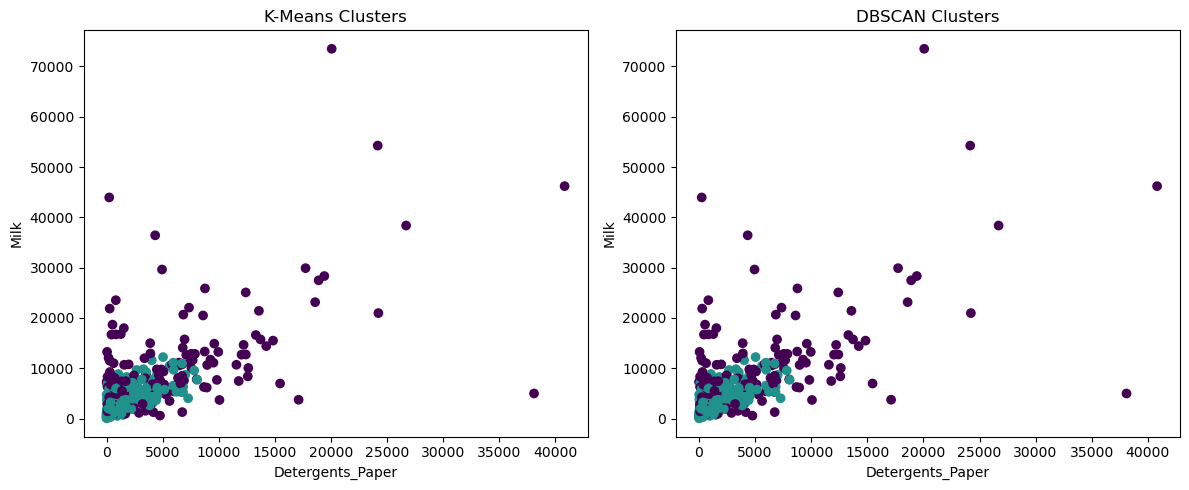

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# --------- Plot 1: K-Means ---------
plt.subplot(1, 2, 1)
plt.scatter(data1['Detergents_Paper'], data1['Milk'], c=data1['labels'])
plt.title("K-Means Clusters")
plt.xlabel("Detergents_Paper")
plt.ylabel("Milk")

# --------- Plot 2: DBSCAN ---------
plt.subplot(1, 2, 2)
plt.scatter(data1['Detergents_Paper'], data1['Milk'], c=data1['DBSCAN_labels'])
plt.title("DBSCAN Clusters")
plt.xlabel("Detergents_Paper")
plt.ylabel("Milk")

plt.tight_layout()
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

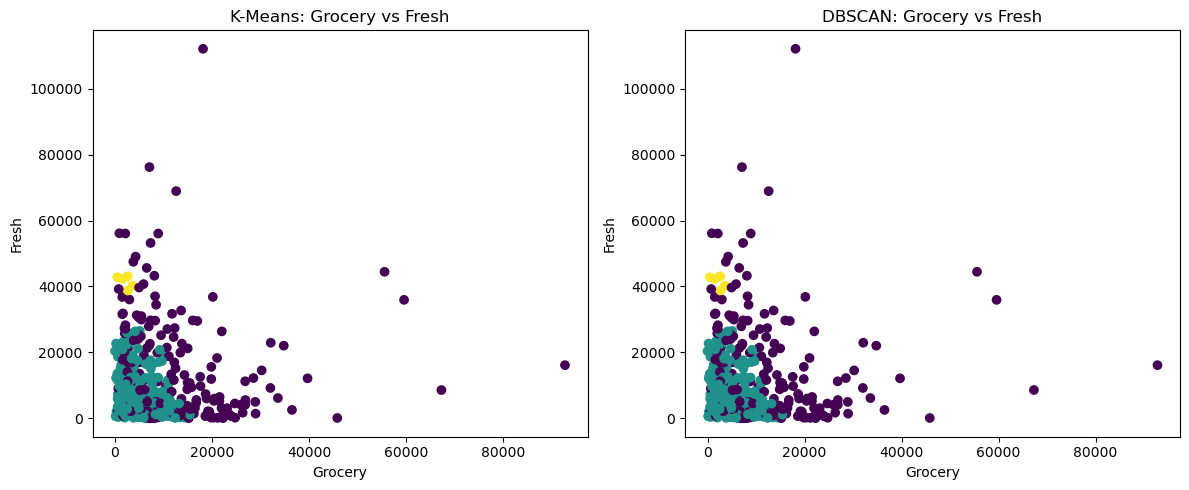

In [115]:
# Your code here:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ----- K-MEANS -----
plt.subplot(1, 2, 1)
plt.scatter(data1['Grocery'], data1['Fresh'], c=data1['labels'])
plt.xlabel('Grocery')
plt.ylabel('Fresh')
plt.title('K-Means: Grocery vs Fresh')

# ----- DBSCAN -----
plt.subplot(1, 2, 2)
plt.scatter(data1['Grocery'], data1['Fresh'], c=data1["DBSCAN_labels"])
plt.xlabel('Grocery')
plt.ylabel('Fresh')
plt.title('DBSCAN: Grocery vs Fresh')

plt.tight_layout()
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

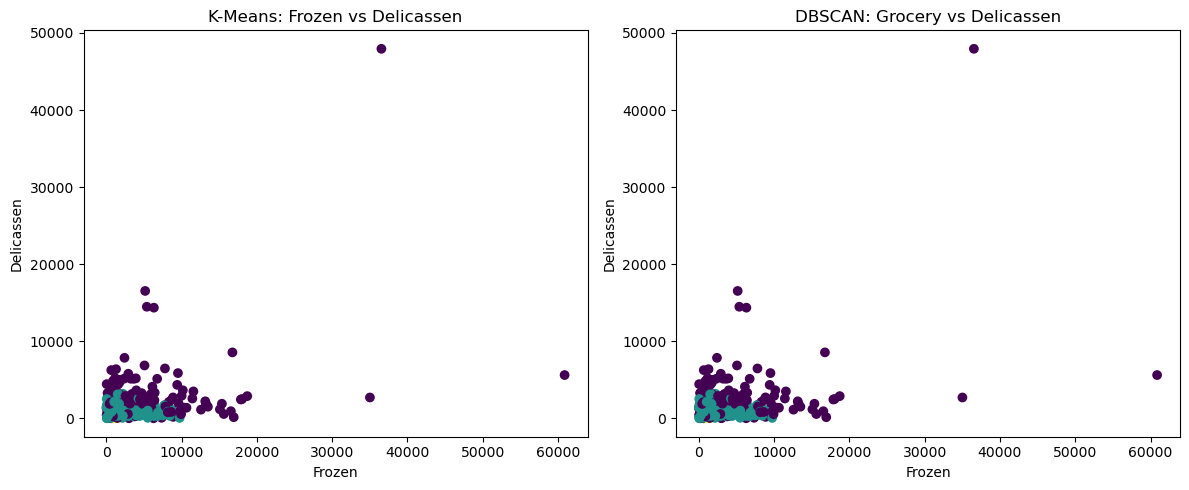

In [116]:
# Your code here:
# Your code here:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ----- K-MEANS -----
plt.subplot(1, 2, 1)
plt.scatter(data1['Frozen'], data1['Delicassen'], c=data1['labels'])
plt.xlabel('Frozen')
plt.ylabel('Delicassen')
plt.title('K-Means: Frozen vs Delicassen')

# ----- DBSCAN -----
plt.subplot(1, 2, 2)
plt.scatter(data1['Frozen'], data1['Delicassen'], c=data1["DBSCAN_labels"])
plt.xlabel('Frozen')
plt.ylabel('Delicassen')
plt.title('DBSCAN: Grocery vs Delicassen')

plt.tight_layout()
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [119]:
# Your code here:
print("=== Means by K-Means clusters ===")
print(data1.groupby(data1['labels']).mean())

=== Means by K-Means clusters ===
               Fresh         Milk       Grocery       Frozen  \
labels                                                         
-1      15979.428571  9645.390110  13198.291209  4809.159341   
 0       8555.897233  3113.794466   4291.047431  1857.711462   
 1      41446.600000  1421.200000   2167.600000  1276.400000   

        Detergents_Paper   Delicassen  DBSCAN_cluster  DBSCAN_labels  
labels                                                                
-1           5073.252747  2445.582418            -1.0           -1.0  
 0           1353.533597   877.166008             0.0            0.0  
 1            416.200000   784.800000             1.0            1.0  


In [123]:
# Your code here:
print("\n=== Means by DBSCAN clusters ===")
print(data1.groupby(data1["DBSCAN_labels"]).mean())


=== Means by DBSCAN clusters ===
                      Fresh         Milk       Grocery       Frozen  \
DBSCAN_labels                                                         
-1             15979.428571  9645.390110  13198.291209  4809.159341   
 0              8555.897233  3113.794466   4291.047431  1857.711462   
 1             41446.600000  1421.200000   2167.600000  1276.400000   

               Detergents_Paper   Delicassen  labels  DBSCAN_cluster  
DBSCAN_labels                                                         
-1                  5073.252747  2445.582418    -1.0            -1.0  
 0                  1353.533597   877.166008     0.0             0.0  
 1                   416.200000   784.800000     1.0             1.0  


Which algorithm appears to perform better?

SyntaxError: invalid syntax (1073517070.py, line 1)

**Your observations here**

- 

Both algorithms have same performance

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [ ]:
# Your code here:

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [ ]:
# Your code here

**Your comment here**

- 